# Proyecto: Clasificador Inteligente de Imágenes de Ropa

## Objetivo
Diseñar, entrenar e implementar un modelo basado en redes neuronales que sea capaz de clasificar imágenes de prendas de vestir (camisetas, zapatillas, pantalones, etc.) en sus respectivas categorías.

## Lección 1: La red neuronal artificial

**Objetivo:** Comprender los elementos de una red neuronal artificial y su rol en la resolución de problemas.

### 1.1 Arquitectura de una red neuronal densa

Una **red neuronal densa (fully connected)** es aquella en la que cada neurona de una capa está conectada con todas las neuronas de la capa siguiente, lo que permite una propagación exhaustiva de la información.

### Características principales

* **Capas densas (Dense Layers):** Cada neurona recibe entradas de todas las neuronas de la capa anterior.
* **Pesos y sesgos:** Cada conexión tiene un peso asociado y cada neurona posee un sesgo que ajusta la salida.
* **Funciones de activación:** Introducen no linealidad, permitiendo que la red aprenda relaciones complejas.
* **Propagación hacia adelante (Forward Propagation):** El cálculo de la salida se realiza mediante multiplicaciones matriciales y funciones de activación.
* **Retropropagación (Backpropagation):** Ajuste de los pesos mediante gradientes para minimizar el error.

### Estructura típica

| Elemento | Descripción |
| --- | --- |
| **Capa de entrada** | Recibe los datos originales (ej. imágenes, texto, señales). |
| **Capas ocultas** | Procesan la información aplicando transformaciones no lineales. |
| **Capa de salida** | Genera la predicción final (ej. clasificación, regresión). |
| **Función de activación** | ReLU, Sigmoid, Tanh, Softmax, según el tipo de problema. |
| **Parámetros entrenables** | Pesos y sesgos que se optimizan durante el entrenamiento. |

### 1.2 Implementación de una red neuronal simple para clasificación binaria

En este proyecto se utiliza el dataset **Fashion-MNIST**, el cual tiene 60.000 imágenes de entrenamiento y 10.000 de prueba, distribuidas en 10 clases distintas, cada una representando un tipo de prenda o accesorio.

En esta lección se implementa una red neuronal para clasificación binaria, utilizando las clases T-shirt/top y Dress.

### Enfoque con máscaras y recodificación de etiquetas                 
Se seleccionan 2 clases: T-shirt/top y Dress, ya que son visualmente similares. Luego se re-etiquetan: Dress pasa a ser la clase 0 y T-shirt/top pasa a ser la clase 1. De esta forma, se dejan las etiquetas directamente en formato binario (0/1).

### 1.3 Aspectos técnicos

**Preprocesamiento**: Normalización de imágenes y conversión de etiquetas a valores binarios (0 y 1).

**Arquitectura:**
* **Flatten** para transformar la imagen 28x28 en un vector de 784 elementos.
* Una capa oculta **Dense(128, relu)** para aprender representaciones no lineales.
* Una capa de salida **Dense(1, sigmoid)** que entrega una probabilidad entre 0 y 1.

**Función de pérdida:** **binary_crossentropy**, adecuada para problemas binarios.

**Métrica:** **accuracy**, para medir la proporción de aciertos.

**Optimización:** **Adam**, ya que ajusta dinámicamente la tasa de aprendizaje, es eficiente y robusto para este tipo de problemas.

**Entrenamiento:** batch_size=32, epochs=10, con validation_split=0.2.

### Carga y exploración del dataset

Se incluye una visualización que permite inspeccionar las imágenes y confirmar que los datos están bien cargados, así como entender la dificultad del problema (algunas clases son visualmente muy similares).

In [ ]:
!pip install scikeras tensorflow keras scikit-learn --upgrade

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Tamaño del conjunto de entrenamiento: (60000, 28, 28)
Tamaño del conjunto de prueba: (10000, 28, 28)


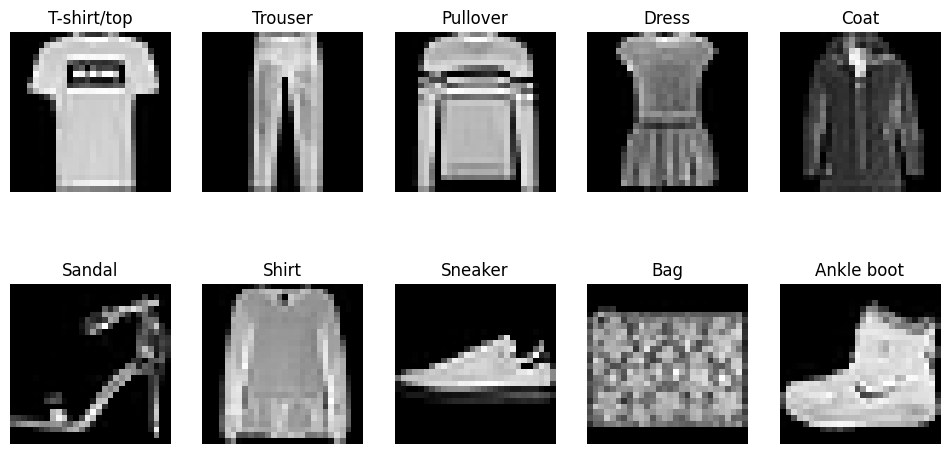

In [2]:
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import fashion_mnist

# 1. Cargar dataset
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

# 2. Normalizar imágenes (valores entre 0 y 1)
x_train = x_train / 255.0
x_test = x_test / 255.0

# 3. Mostrar dimensiones
print("Tamaño del conjunto de entrenamiento:", x_train.shape)
print("Tamaño del conjunto de prueba:", x_test.shape)

# 4. Definir etiquetas de las clases (según documentación oficial)
class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
               "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

# 5. Visualizar una imagen representativa de cada categoría
fig, axes = plt.subplots(2, 5, figsize=(12, 6))
for i in range(10):
    idx = (y_train == i).nonzero()[0][0]  # primer índice de la clase i
    axes[i//5, i%5].imshow(x_train[idx], cmap='gray')
    axes[i//5, i%5].set_title(class_names[i])
    axes[i//5, i%5].axis('off')
plt.show()

### Implementación red neuronal para clasificación binaria (T-shirt/top vs Dress)

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Input

# 1. Seleccionar dos clases: T-shirt/top (0) y Dress (3)
binary_train_mask = (y_train == 0) | (y_train == 3)
binary_test_mask = (y_test == 0) | (y_test == 3)

x_train_bin = x_train[binary_train_mask]
y_train_bin = (y_train[binary_train_mask] == 0).astype(int)  # T-shirt/top=1, Dress=0

x_test_bin = x_test[binary_test_mask]
y_test_bin = (y_test[binary_test_mask] == 0).astype(int)

x_train_bin.shape, x_test_bin.shape

((12000, 28, 28), (2000, 28, 28))

In [4]:
# 2. Construcción del modelo binario
model_bin = Sequential([
    Input(shape=(28,28)),                   # Definir la forma de entrada
    Flatten(),                              # Aplanar la imagen
    Dense(128, activation='relu'),          # Capa oculta
    Dense(1, activation='sigmoid')          # Capa de salida binaria
])

model_bin.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 100,609 (393.00 KB)

 Trainable params: 100,609 (393.00 KB)

 Non-trainable params: 0 (0.00 B)

In [5]:
# 3. Compilación
model_bin.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

# 4. Entrenamiento
history_bin = model_bin.fit(x_train_bin, y_train_bin, epochs=10, batch_size=32, validation_split=0.2, verbose=1)

# 5. Evaluación
loss_bin, acc_bin = model_bin.evaluate(x_test_bin, y_test_bin)
print(f"Accuracy en test (binario): {acc_bin:.4f}")

Epoch 1/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9215 - loss: 0.2022 - val_accuracy: 0.9367 - val_loss: 0.1647
Epoch 2/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9395 - loss: 0.1580 - val_accuracy: 0.9446 - val_loss: 0.1465
Epoch 3/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9478 - loss: 0.1356 - val_accuracy: 0.9554 - val_loss: 0.1272
Epoch 4/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9556 - loss: 0.1186 - val_accuracy: 0.9608 - val_loss: 0.1128
Epoch 5/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9600 - loss: 0.1087 - val_accuracy: 0.9621 - val_loss: 0.1113
Epoch 6/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9651 - loss: 0.0970 - val_accuracy: 0.9588 - val_loss: 0.1208
Epoch 7/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9656 - loss: 0.0919 - val_accuracy: 0.9667 - val_loss: 0.0975
Epoch 8/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9680 - loss: 0.0856 - val_accuracy: 0.

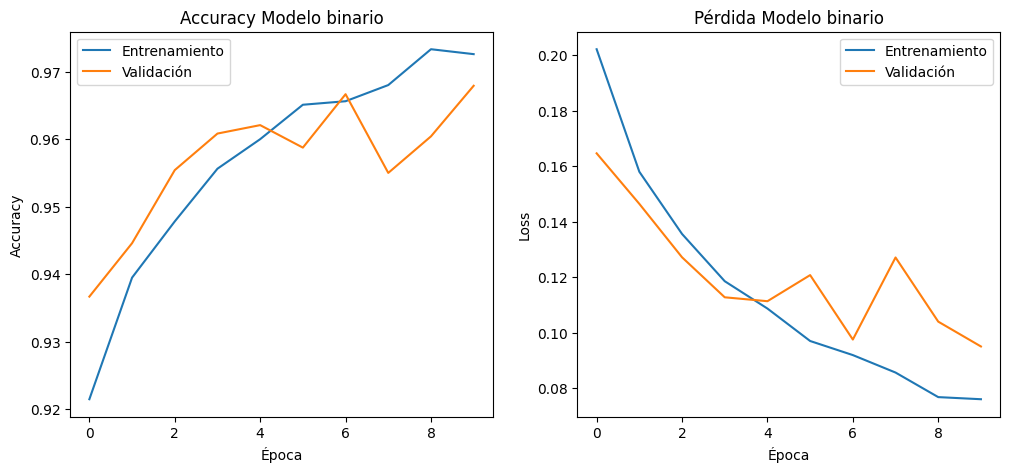

In [6]:
# 6. Gráficos de accuracy y pérdida
plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history_bin.history['accuracy'], label='Entrenamiento')
plt.plot(history_bin.history['val_accuracy'], label='Validación')
plt.title('Accuracy Modelo binario')
plt.xlabel('Época')
plt.ylabel('Accuracy')
plt.legend()

# Pérdida
plt.subplot(1,2,2)
plt.plot(history_bin.history['loss'], label='Entrenamiento')
plt.plot(history_bin.history['val_loss'], label='Validación')
plt.title('Pérdida Modelo binario')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()

plt.show()

### Interpretación de Resultados

**Accuracy**            
* **Entrenamiento**: la curva sube de ~0.92 hasta superar 0.97, lo que indica que el modelo aprende de manera consistente.

* **Validación**: se mantiene estable entre 0.94 y 0.96, sin caídas bruscas. Eso sugiere que el modelo generaliza bien y no está sobreajustando de forma marcada.

**Pérdida**
* **Entrenamiento**: baja de ~0.20 a 0.07, lo que confirma que el modelo está optimizando correctamente.

* **Validación**: desciende también, aunque con más fluctuaciones (entre 0.16 y 0.09). Esa variabilidad es normal, porque depende de cómo se particionó el conjunto de validación.

**Interpretación**                         
* El modelo binario logra alta precisión (>95%) en validación, lo que es un excelente resultado para distinguir entre dos clases relativamente similares (T-shirt/top vs Dress).

* No se observa un gap grande entre entrenamiento y validación, lo que indica que no hay sobreajuste fuerte.

* Las pequeñas oscilaciones en la validación son esperables y reflejan la sensibilidad del modelo a los datos de validación.

### Conclusión
El modelo binario está bien diseñado y entrenado:

* Aprende de manera estable.

* Generaliza correctamente.

* Tiene un desempeño alto y consistente.

## Lección 2: Deep Learning

**Objetivo:** Reconocer las principales arquitecturas, usos y frameworks
de Deep Learning.

### 2.1 Arquitectura óptima para clasificación de imágenes

La arquitectura óptima para este proyecto corresponde a las **Redes Convolucionales (CNN, Convolutional Neural Networks)**, ya que están diseñadas específicamente para procesar datos con estructura espacial (imágenes).

Las CNN utilizan filtros convolucionales que aprenden patrones locales (bordes, texturas, formas) y los combinan en niveles más altos (objetos completos).

#### **Componentes de una CNN**

*   **Capas Convolutivas:** Realizan operaciones convolutivas para extraer características espaciales de las imágenes.
*   **Funciones de Activación:** Introducen no linealidad al modelo, permitiendo aprender patrones complejos.
*   **Capas de Pooling:** Reducen la dimensionalidad manteniendo la información más relevante.
*   **Capas densas:** Realizan la clasificación final basada en las características
extraídas.








### 2.2 Justificación Red Densa vs Red Convolutiva

A continuación se presenta una comparativa con las principales diferencias entre la red densa y la red convolutiva.

| Aspecto | Red Densa (Fully Connected) | Red Convolutiva (CNN) |
| --- | --- | --- |
| **Parámetros** | Muy alta cantidad (784 entradas × 128 neuronas = ~100k pesos solo en la primera capa). | Menor cantidad gracias a filtros compartidos. |
| **Estructura espacial** | Pierde la relación espacial al aplanar la imagen. | Conserva la estructura espacial y aprende patrones locales. |
| **Generalización** | Tiende a sobreajustar si no se regula. | Generaliza mejor en imágenes, incluso con datasets grandes. |
| **Uso típico** | Problemas tabulares o binarios simples. | Clasificación de imágenes, visión por computador. |


Por tanto, para el datset Fashion-MNIST, una red densa funciona como introducción, pero la arquitectura óptima para clasificación de imágenes es una CNN, porque aprovecha la naturaleza espacial de los datos.

### 2.3 Selección de framework: Keras vs PyTorch

El framework elegido es **Keras**, por su simplicidad, rapidez de prototipado y claridad pedagógica, lo que lo hace ideal para este proyecto.

#### **Comparativa:**

**Keras (sobre TensorFlow)**       
*   Sintaxis muy simple y amigable.
*   Ideal para prototipado rápido y enseñanza.
*   Gran ecosistema de herramientas integradas (callbacks, visualización, deployment).

**PyTorch**
*   Más flexible y cercano al control de bajo nivel.
*   Preferido en investigación y desarrollo experimental.
*   Comunidad académica muy activa, integración con frameworks de última generación.

**Conclusión:** se selecciona **Keras**, ya que permite construir y entrenar modelos de manera rápida y clara, facilita la visualización y documentación de resultados y resulta suficiente para el dataset Fashion-MNIST y para ilustrar la transición de una red densa a una convolutiva.

## Lección 3: Implementación de Redes Neuronales en Python

**Objetivo:** Diseñar y entrenar una red neuronal en Python para resolver un problema de clasificación de imágenes del dataset Fashion-MNIST.

## 3.1 Implementación del modelo y ajuste de hiperparámetros

Se implementa un modelo funcional para clasificar imágenes del dataset Fashion-MNIST, aplicando técnicas de optimización y regularización.

### Características técnicas:

**Arquitectura del modelo:**
* **Entrada:** imágenes 28x28, aplanadas a vectores de 784.
* **Dos capas densas ocultas:** 256 y 128 neuronas con activación ReLU para capturar patrones complejos.
* **Capas de Dropout (30%)** para reducir sobreajuste.
 * **Capa de salida con 10 neuronas** y activación **softmax** para clasificación multiclase.

**Optimización:**
* Optimizador **Adam.**
* **Pérdida:** **sparse_categorical_crossentropy**, adecuada cuando las etiquetas son enteros.
* **Métrica: accuracy.**

**Entrenamiento y validación:**
* 15 épocas, batch size de 256, con validation_split=0.2.
* Evaluación final en el conjunto de prueba.

In [7]:
from tensorflow.keras.layers import Dropout, Input
from tensorflow.keras.optimizers import Adam

# 1. Se aplanan las imágenes a vectores de 784 elementos
x_train_dense = x_train
x_test_dense  = x_test
y_train_dense = y_train
y_test_dense  = y_test

# 2. Construcción del modelo denso
model_dense = Sequential([
    Input(shape=(28,28)),          # Entrada: imágenes 28x28
    Flatten(),                     # Aplanar a vector de 784
    Dense(256, activation="relu"), # Capa oculta 1
    Dropout(0.3),                  # Regularización
    Dense(128, activation="relu"), # Capa oculta 2
    Dropout(0.3),
    Dense(10, activation="softmax") # Salida multiclase
])

model_dense.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 235,146 (918.54 KB)

 Trainable params: 235,146 (918.54 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
# 3. Compilación
model_dense.compile(optimizer='adam',
                    loss="sparse_categorical_crossentropy",
                    metrics=["accuracy"])

# 4. Entrenamiento con validación
history_dense = model_dense.fit(x_train_dense, y_train_dense,
                          validation_split=0.2,
                          epochs=15, batch_size=256,
                          verbose=1)

# 5. Evaluación final
loss_dense, acc_dense = model_dense.evaluate(x_test_dense, y_test_dense)
print(f"Accuracy en test (multiclase): {acc_dense:.4f}")


Epoch 1/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.7450 - loss: 0.7228 - val_accuracy: 0.8388 - val_loss: 0.4532
Epoch 2/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.8352 - loss: 0.4675 - val_accuracy: 0.8559 - val_loss: 0.3928
Epoch 3/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.8510 - loss: 0.4146 - val_accuracy: 0.8697 - val_loss: 0.3637
Epoch 4/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.8596 - loss: 0.3891 - val_accuracy: 0.8674 - val_loss: 0.3576
Epoch 5/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.8674 - loss: 0.3655 - val_accuracy: 0.8743 - val_loss: 0.3434
Epoch 6/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.8724 - loss: 0.3524 - val_accuracy: 0.8784 - val_loss: 0.3339
Epoch 7/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.8765 - loss: 0.3424 - val_accuracy: 0.8805 - val_loss: 0.3283
Epoch 8/15
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.8781 - loss: 0.3313 - val_accu

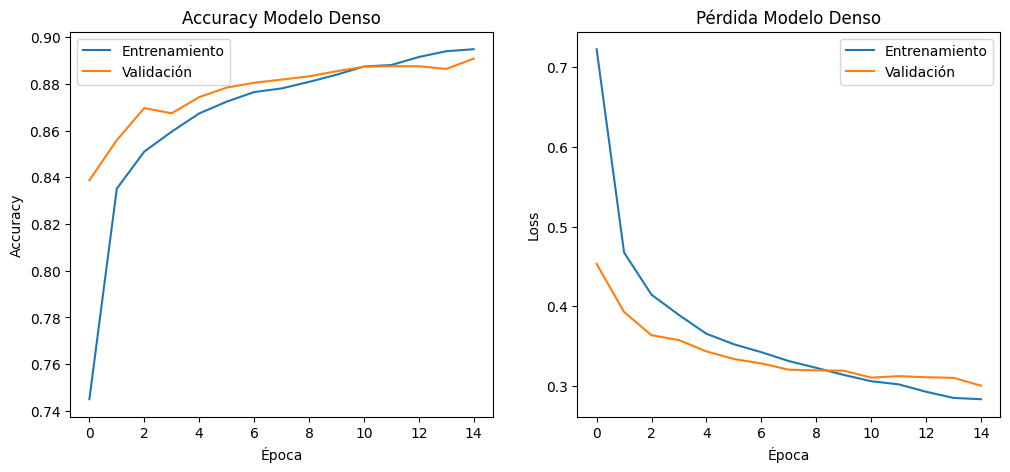

In [9]:
# 6. Gráficos de desempeño
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history_dense.history['accuracy'], label='Entrenamiento')
plt.plot(history_dense.history['val_accuracy'], label='Validación')
plt.title('Accuracy Modelo Denso')
plt.xlabel('Época')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history_dense.history['loss'], label='Entrenamiento')
plt.plot(history_dense.history['val_loss'], label='Validación')
plt.title('Pérdida Modelo Denso')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()

plt.show()

### Interpretación de Resultados

**Accuracy**
* **Entrenamiento**: la curva sube de manera progresiva hasta ~0.89, lo que indica que el modelo está capturando patrones útiles.

* **Validación**: sigue una trayectoria muy similar, alcanzando también cerca de 0.89. Esto es positivo porque significa que el modelo generaliza bien y no se queda “memorizando” solo el set de entrenamiento.

**Pérdida**
* **Entrenamiento**: baja de ~0.7 a menos de 0.3, mostrando que la optimización funciona.

* **Validación**: desciende casi en paralelo, lo que refuerza la idea de que el modelo no está sobreajustando de manera significativa.

**Interpretación**
* El modelo logra un accuracy cercano al 88% en un problema multiclase con 10 categorías, lo cual es un buen desempeño para una red densa sin convoluciones.

* La cercanía entre las curvas de entrenamiento y validación indica que el modelo está bien regularizado (el Dropout ayuda mucho aquí).

* No hay señales claras de sobreajuste: las curvas son estables y no divergen.

### Conclusiones

* El modelo logra capturar patrones relevantes en las imágenes, pero al tratarse de un problema multiclase con mayor complejidad, la precisión es menor que en el caso binario.

* La inclusión de Dropout ayudó a controlar el sobreajuste, manteniendo las curvas de entrenamiento y validación relativamente alineadas.

* Sin embargo, al no explotar la estructura espacial de las imágenes (como sí lo hace una CNN), la red densa presenta limitaciones en la extracción de características visuales más profundas.

## Lección 4: Redes Neuronales Convolutivas

**Objetivo:** Integrar una red convolutiva para mejorar la capacidad predictiva
del modelo.

## 4.1 Rediseño de la Arquitectura (CNN)

La CNN aprovecha la estructura espacial de las imágenes, detectando bordes, texturas y patrones jerárquicos. Esto suele traducirse en mayor precisión que las redes densas, especialmente en datasets de imágenes, por lo que su implementación permite superar las limitaciones abordadas con la red densa.

### Aspectos técnicos

* **Preprocesamiento:** Ajuste de dimensiones para incluir el canal de entrada (28,28,1).

* **Arquitectura:**
  * Dos bloques de convolución y pooling:
    * Conv2D(32, (3,3), relu) + MaxPooling2D(2,2)
    * Conv2D(64, (3,3), relu) + MaxPooling2D(2,2)
  * Flatten para vectorizar las características extraídas.
  * Dense(128, relu) + Dropout(0.3) para aprendizaje profundo y regularización.
  * Capa de salida Dense(10, softmax) para clasificación multiclase.

* **Función de pérdida:** sparse_categorical_crossentropy, ya que las etiquetas son números enteros (0-9).

* **Entrenamiento:** batch_size=128, epochs=10, con validation_split=0.2.

In [10]:
from tensorflow.keras.layers import Conv2D, MaxPooling2D

# 1. Ajustar dimensiones para CNN (añadir canal)
x_train_cnn = x_train.reshape(-1, 28, 28, 1)
x_test_cnn  = x_test.reshape(-1, 28, 28, 1)
y_train_cnn = y_train
y_test_cnn  = y_test

# 2. Construcción del modelo convolutivo
model_cnn = Sequential([
    Input(shape=(28,28,1)),
    Conv2D(32, (3,3), activation="relu"),
    MaxPooling2D((2,2)),
    Conv2D(64, (3,3), activation="relu"),
    MaxPooling2D((2,2)),
    Flatten(),
    Dense(128, activation="relu"),
    Dropout(0.3),
    Dense(10, activation="softmax")
])

model_cnn.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
# 3. Compilación
model_cnn.compile(optimizer='adam',
                  loss="sparse_categorical_crossentropy",
                  metrics=["accuracy"])

# 4. Entrenamiento con validación
history_cnn = model_cnn.fit(x_train_cnn, y_train_cnn,
                            validation_split=0.2,
                            epochs=10, batch_size=128,
                            verbose=1)

# 5. Evaluación final
loss_cnn, acc_cnn = model_cnn.evaluate(x_test_cnn, y_test_cnn)
print(f"Accuracy en test (CNN): {acc_cnn:.4f}")

Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 29s 73ms/step - accuracy: 0.7706 - loss: 0.6355 - val_accuracy: 0.8567 - val_loss: 0.4071
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 27s 71ms/step - accuracy: 0.8580 - loss: 0.3952 - val_accuracy: 0.8668 - val_loss: 0.3608
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 27s 73ms/step - accuracy: 0.8784 - loss: 0.3397 - val_accuracy: 0.8874 - val_loss: 0.3071
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 40s 71ms/step - accuracy: 0.8873 - loss: 0.3092 - val_accuracy: 0.8953 - val_loss: 0.2917
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 31s 82ms/step - accuracy: 0.8954 - loss: 0.2883 - val_accuracy: 0.8981 - val_loss: 0.2800
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 38s 73ms/step - accuracy: 0.9007 - loss: 0.2721 - val_accuracy: 0.9032 - val_loss: 0.2636
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 40s 72ms/step - accuracy: 0.9076 - loss: 0.2532 - val_accuracy: 0.9071 - val_loss: 0.2554
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 41s 73ms/step - accuracy: 0.9117 - loss: 0.2420 - 

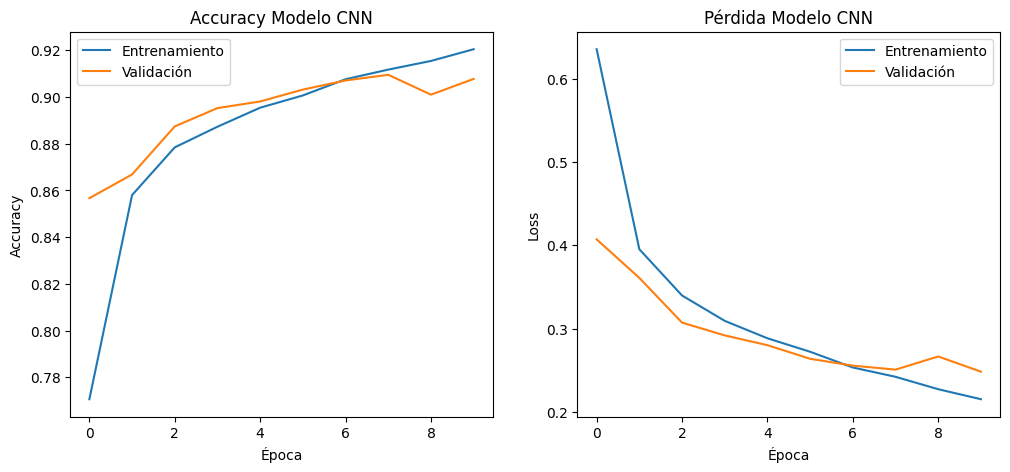

In [12]:
# 6. Visualización de Métricas CNN
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history_cnn.history['accuracy'], label='Entrenamiento')
plt.plot(history_cnn.history['val_accuracy'], label='Validación')
plt.title('Accuracy Modelo CNN')
plt.xlabel('Época')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history_cnn.history['loss'], label='Entrenamiento')
plt.plot(history_cnn.history['val_loss'], label='Validación')
plt.title('Pérdida Modelo CNN')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()

plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step


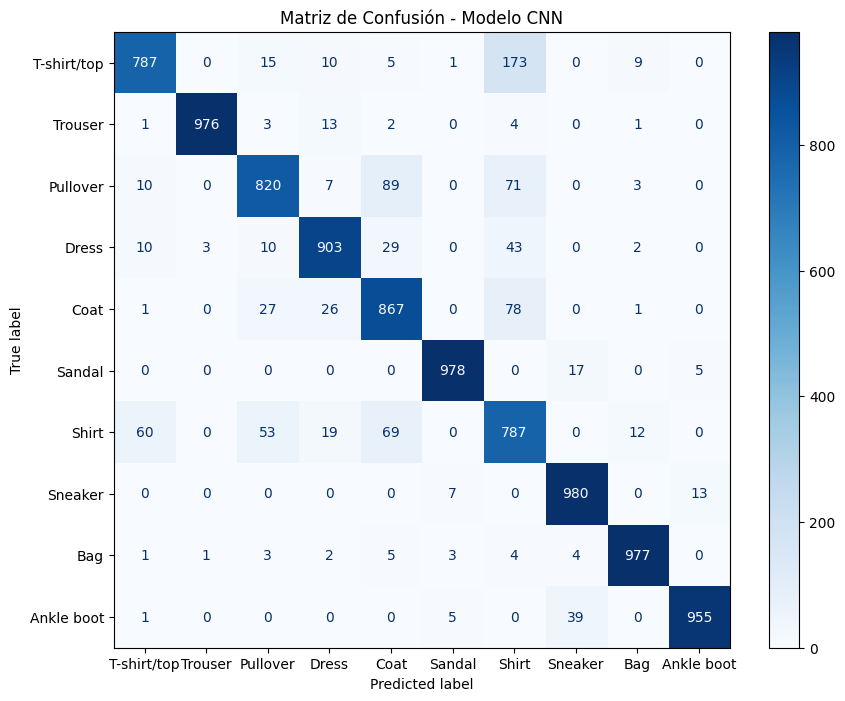

In [13]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 7. Matriz de confusión
# Obtener predicciones
y_pred_cnn = model_cnn.predict(x_test_cnn)
y_pred_classes = y_pred_cnn.argmax(axis=1)  # clase con mayor probabilidad

# Calcular matriz de confusión
cm = confusion_matrix(y_test_cnn, y_pred_classes)

# Visualizar matriz de confusión
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
fig, ax = plt.subplots(figsize=(10, 8))
disp.plot(ax=ax, cmap="Blues", values_format="d")
plt.title("Matriz de Confusión - Modelo CNN")
plt.show()

### Interpretación de los Resultados

**Accuracy**
* **Entrenamiento**: la curva sube de ~0.77 hasta superar 0.92 en apenas 10 épocas, lo que indica que el modelo está capturando patrones visuales de manera eficiente.

* **Validación**: sigue una trayectoria muy similar, alcanzando también valores cercanos a 0.90-0.91. Esa cercanía entre ambas curvas es una señal de buena generalización.

**Pérdida**
* **Entrenamiento**: baja de ~0.6 a ~0.2, mostrando que el error se reduce de forma consistente.

* **Validación**: desciende en paralelo, sin divergencias marcadas, lo que indica que el modelo no está sobreajustando.

**Interpretación**
* La CNN logra mejor desempeño que la red densa: supera el 90% de accuracy en validación, mientras que la red densa se quedó en torno al 88%.

* La diferencia entre entrenamiento y validación es pequeña, lo que sugiere que el modelo está bien regularizado (el Dropout ayuda a evitar sobreajuste).

* El aprendizaje es rápido: en solo 10 épocas ya alcanza un nivel alto de precisión, lo que refleja la eficiencia de las convoluciones para extraer características espaciales.

### Matriz de Confusión

La matriz de confusión cruza la categoría real con la predicción del modelo.
En la **diagonal principal** se muestran los **Aciertos**, mientras que los valores fuera de la diagonal representan los **Errores o Confusiones**.

**Clases muy bien reconocidas**
* **Trouser**, **Sandal**, **Sneaker** y **Bag** tienen más altos aciertos y muy pocos errores.

* **Ankle boot** mantiene un alto nivel de aciertos (935), aunque con algunos desvíos hacia la clase Sneaker.

Esto confirma que el modelo CNN distingue muy bien categorías con formas claras y diferentes.

**Áreas de confusión**
* **T-shirt/top vs Shirt**: es la mayor fuente de error. Hay más de 170 confusiones, lo que refleja la dificultad del modelo para separar prendas superiores de aspecto similar.

* **Pullover, Dress y Coat**: se observan errores cruzados entre estas tres clases (ej. Coat confundido con Pullover o Dress). Son prendas con siluetas parecidas y el modelo tiende a mezclarlas.

* **Shirt** vs otras clases:  además de confundirse con T-shirt/top, también hay errores hacia Coat y Pullover, lo que muestra que Shirt es la categoría más problemática.

### Conclusiones

* La CNN logra extraer características espaciales relevantes (bordes, texturas, patrones jerárquicos) que las redes densas no capturan.

* El uso de Dropout contribuyó a controlar el sobreajuste, manteniendo las curvas de validación alineadas con las de entrenamiento.

* El desempeño en test confirma que el modelo es capaz de generalizar adecuadamente, con una precisión superior al 90%, lo que lo convierte en una solución robusta para clasificación de imágenes, no obstante, la matriz de confusión revela que los errores se concentran en clases con alta similitud visual.

## 4.2 Comparación Red Densa vs CNN

In [14]:
import pandas as pd

# Evaluación de ambos modelos en el conjunto de test
loss_d, acc_d = model_dense.evaluate(x_test_dense, y_test_dense, verbose=0)
loss_c, acc_c = model_cnn.evaluate(x_test_cnn, y_test_cnn, verbose=0)

# Crear tabla comparativa
df_comparativo = pd.DataFrame({
    'Métrica': ['Test Accuracy', 'Test Loss'],
    'Red Densa (MLP)': [acc_d, loss_d],
    'Red Convolutiva (CNN)': [acc_c, loss_c]
})

print("\nCOMPARATIVA DE MODELOS:")
print(df_comparativo)


COMPARATIVA DE MODELOS:
         Métrica  Red Densa (MLP)  Red Convolutiva (CNN)
0  Test Accuracy         0.882600               0.903000
1      Test Loss         0.328971               0.264002


**Diferencias observadas**
* **Accuracy en test**: la CNN alcanza un valor más alto que la red densa, lo que confirma que las convoluciones capturan mejor las características espaciales de las imágenes.

* **Pérdida en test**: la CNN obtiene una pérdida más baja, lo que indica que sus predicciones son más seguras y consistentes.

**Interpretación**
* La red densa logra un desempeño respetable (~88% de accuracy), pero depende de aplanar las imágenes, perdiendo información espacial.

* La CNN aprovecha la estructura bidimensional de las imágenes, detectando bordes, texturas y patrones locales, lo que se traduce en mejor rendimiento.

* La diferencia en pérdida también es importante: no solo acierta más, sino que lo hace con mayor confianza.

### Conclusiones

* La CNN supera a la red densa en términos de precisión y estabilidad de entrenamiento.

* El modelo presenta un equilibrio entre alto rendimiento y buena generalización, consolidándose como la mejor opción entre los tres enfoques evaluados (binario, denso y CNN).

* Estos resultados evidencian que, para problemas de visión por computadora, las redes convolutivas son la arquitectura más adecuada, ya que aprovechan la estructura espacial de los datos y logran un desempeño superior.

## 4.3 Predicciones visuales

Se prueba el modelo de red convolutiva (CNN) con una imagen para probar su desempeño. A modo de ejemplo, se utiliza una imagen de la clase Ankle boot, logrando el modelo clasificarla de manera correcta.

Se debe tener presente que el dataset Fashion-MNIST tiene imágenes muy simplificadas y estilizadas (28x28 en escala de grises), por lo que al usar fotos reales es posible que el modelo no prediga bien porque no fue entrenado con imágenes reales, sino con dibujos estilizados.


Saving ankle_boot.png to ankle_boot.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step


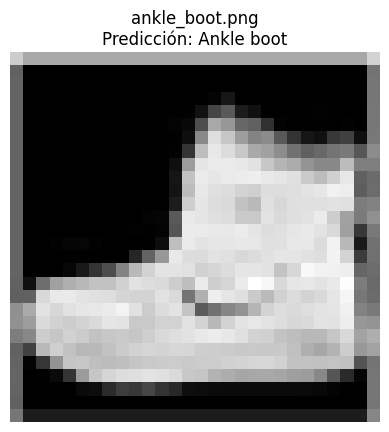

In [36]:
from google.colab import files
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# 1. Subir una imagen desde el computador
uploaded = files.upload()  # seleccionar un archivo

# 2. Función de preprocesamiento
def preprocess_image(path):
    img = Image.open(path).convert("L")   # escala de grises
    img = img.resize((28, 28))            # redimensionar
    img_array = np.array(img) / 255.0     # normalizar
    img_array = np.expand_dims(img_array, axis=-1)  # canal
    img_array = np.expand_dims(img_array, axis=0)   # batch
    return img_array

# 3. Tomar el primer archivo subido
filename = list(uploaded.keys())[0]
img_array = preprocess_image(filename)

# 4. Predicción
pred = model_cnn.predict(img_array)
pred_class = pred.argmax(axis=1)[0]

# 5. Mostrar imagen y predicción
plt.imshow(img_array[0].reshape(28,28), cmap="gray")
plt.title(f"{filename}\nPredicción: {class_names[pred_class]}")
plt.axis("off")
plt.show()